# Figure 4 — Analyzing the frozen foundation representation: decodability and information routing

Two complementary views of the frozen bottleneck.

**Left — decodability (probe).** A probe predicts each band's per-source brightness (log SNR) from
the frozen features at detected source positions; 6-fold spatial hold-out, ~1000 sources; features
standardized per fold, ridge alpha cross-validated, per-band regression restricted to sources with
signal in that band (drops ~1.5% pure-noise non-detections). Open = linear ridge, filled = nonlinear
MLP, line = nonlinear gain, gray bar = fold scatter. All ten bands are linearly decodable
(R²≈0.7–0.92). VIS reads back lowest only because sources are *selected* on VIS S/N (truncated range).

**Right — information routing (attribution).** Input-gradient attribution: mask a target band,
backprop the reconstruction loss to each source band's pixels (mean|grad|/mean|input|),
row-normalized. **VIS is removed** because, present, it absorbs ~100% of the attribution (universal
spatial scaffold); shown is the routing among the other nine bands. n_eff = 2^H (Shannon entropy of
each row) = effective number of source bands: Rubin ~4–7 (g/r hub + neighbours + NISP), NISP ~2–3
(near-closed Y/J/H block).

Data: `io/_nb13_outputs/cross_instrument_summary_v10_fixed.json` and `attribution_v10_novis.json`,
both produced by the **regeneration cell above** (`REGEN=True`). Saves `paper/figures/fig4_probe.png`.

In [1]:
# ============================================================================
# REGENERATION (guarded). Set REGEN=True to recompute the two JSONs this figure
# reads: cross_instrument_summary_v10_fixed.json (decodability probe) and
# attribution_v10_novis.json (information routing). ~10-15 min on GPU. With
# REGEN=False the notebook just loads the committed JSONs and plots (seconds).
# Folds the former scratchpad generators into the committed notebook.
# ============================================================================
REGEN = True

if REGEN:
    import sys, json, gc
    from pathlib import Path
    import numpy as np, torch, torch.nn as nn
    from scipy.ndimage import gaussian_filter, maximum_filter
    from sklearn.linear_model import RidgeCV
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import r2_score

    ROOT = next(c for c in [Path.cwd(), *Path.cwd().parents] if (c/'data').is_dir() and (c/'paper').is_dir())
    for p in (ROOT, ROOT/'models'):
        if str(p) not in sys.path: sys.path.insert(0, str(p))
    from load_foundation import load_foundation
    from jaisp_foundation_v10 import ALL_BANDS, RUBIN_BANDS, EUCLID_BANDS, band_group, STREAM_PIXEL_SCALES
    from models.older_architectures.jaisp_dataset_v6 import JAISPDatasetV6
    from models.older_architectures.jaisp_dataset_v8 import random_crop_sample

    DEV = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    OUT = ROOT/'io'/'_nb13_outputs'
    CKPT = ROOT/'models'/'checkpoints'/'jaisp_v10_q1_long'/'checkpoint_best.pt'
    N_TILES=60; KFOLD=6; CROP=256; SEED=13013
    SNR_THR=5.0; MIN_DIST=8; MIN_TEST=8; MIN_TRAIN=30; MAX_PEAKS=2000
    TARGET_FLOOR=-0.5; ALPHAS=np.logspace(-1,4,12)

    ds = JAISPDatasetV6(rubin_dir=str(ROOT/'data'/'rubin_tiles_all'),
                        euclid_dir=str(ROOT/'data'/'euclid_tiles_all_q1'), load_euclid=True, augment=False)
    sel=[]
    for idx in range(len(ds)):
        if len(sel)>=N_TILES: break
        s=ds[idx]
        if s['has_euclid'] and all(b in (set(s['rubin'])|set(s['euclid'])) for b in ALL_BANDS): sel.append(idx)
    crop = lambda idx,ti: random_crop_sample(ds[idx], CROP, np.random.RandomState(SEED+int(idx)*1009+int(ti)))
    def bdicts(s):
        im,rm={},{}
        for g in ('rubin','euclid'):
            for b,d in s[g].items():
                im[b]=d['image'].to(DEV).unsqueeze(0).float(); rm[b]=d['rms'].to(DEV).unsqueeze(0).float()
        return im,rm
    def peaks(vi,vr):
        sm=gaussian_filter(vi/np.maximum(vr,1e-9),1.5); lm=maximum_filter(sm,size=MIN_DIST)==sm
        ys,xs=np.where(lm&(sm>SNR_THR)&(vr>0))
        if len(ys)>MAX_PEAKS:
            o=np.argsort(sm[ys,xs])[::-1][:MAX_PEAKS]; ys,xs=ys[o],xs[o]
        return ys,xs

    model = load_foundation(str(CKPT), device=DEV, freeze=True); model.eval()
    fused = model.encoder.fused_pixel_scale_arcsec

    # ---- (1) decodability probe: standardized features + RidgeCV + MLP, per-band signal mask ----
    @torch.no_grad()
    def source_features(s):
        im,rm=bdicts(s); bn=model.encode(context_images=im,context_rms=rm)['bottleneck']
        _,C,Hb,Wb=bn.shape; vi=im['euclid_VIS'][0,0].cpu().numpy(); vr=rm['euclid_VIS'][0,0].cpu().numpy()
        ys,xs=peaks(vi,vr)
        by=(ys*STREAM_PIXEL_SCALES['euclid']/fused).astype(int); bx=(xs*STREAM_PIXEL_SCALES['euclid']/fused).astype(int)
        k=(by>=4)&(by<Hb-4)&(bx>=4)&(bx<Wb-4); by,bx=by[k],bx[k]
        if len(by)==0: return np.zeros((0,C),np.float32),{}
        feats=bn[0,:,by,bx].T.cpu().numpy().astype(np.float32); tg={}
        for b in ALL_BANDS:
            nb_=STREAM_PIXEL_SCALES[band_group(b)]; r=fused/nb_
            yn=np.clip((by*r).astype(int),2,im[b].shape[-2]-3); xn=np.clip((bx*r).astype(int),2,im[b].shape[-1]-3)
            it=im[b][0,0].cpu().numpy(); rt=rm[b][0,0].cpu().numpy(); v=np.zeros(len(by),np.float32)
            for j in range(len(by)):
                y,x=yn[j],xn[j]; v[j]=np.log10(max(it[y-2:y+3,x-2:x+3].mean()/(rt[y-2:y+3,x-2:x+3].mean()+1e-9),1e-3))
            tg[b]=v
        return feats,tg
    class MLP(nn.Module):
        def __init__(s,d,h=128):
            super().__init__(); s.net=nn.Sequential(nn.Linear(d,h),nn.GELU(),nn.Dropout(0.1),nn.Linear(h,h),nn.GELU(),nn.Linear(h,1))
        def forward(s,x): return s.net(x).squeeze(-1)
    def train_mlp(Xtr,ytr,Xte,yte,epochs=120):
        Xt=torch.from_numpy(Xtr).float().to(DEV); yt=torch.from_numpy(ytr).float().to(DEV); Xe=torch.from_numpy(Xte).float().to(DEV)
        m=MLP(Xtr.shape[1]).to(DEV); opt=torch.optim.AdamW(m.parameters(),lr=2e-3,weight_decay=1e-4)
        sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs); best=-1e9
        for _ in range(epochs):
            m.train(); perm=torch.randperm(len(Xt),device=DEV)
            for i in range(0,len(Xt),256):
                sl=perm[i:i+256]; loss=((m(Xt[sl])-yt[sl])**2).mean(); opt.zero_grad(); loss.backward(); opt.step()
            sch.step(); m.eval()
            with torch.no_grad(): p=m(Xe).cpu().numpy()
            best=max(best,1.0-((yte-p)**2).sum()/max(((yte-yte.mean())**2).sum(),1e-9))
        return float(best)
    torch.manual_seed(0); np.random.seed(0)
    F,Tg,tid=[],{b:[] for b in ALL_BANDS},[]
    for ti,idx in enumerate(sel):
        f,tg=source_features(crop(idx,ti))
        if len(f)==0: continue
        F.append(f); [Tg[b].append(v) for b,v in tg.items()]; tid.append(np.full(len(f),ti,np.int32))
    X=np.concatenate(F); Y={b:np.concatenate(v) for b,v in Tg.items()}; T=np.concatenate(tid)
    uniq=list(np.unique(T)); fold=np.array([uniq.index(t)%KFOLD for t in T])
    rg,mp,rgsd,mpsd,nk={},{},{},{},{}
    for b in ALL_BANDS:
        y=Y[b]; m=y>TARGET_FLOOR; Xb,yb,fb=X[m],y[m],fold[m]; nk[b]=int(m.sum()); rf,mf=[],[]
        for k in range(KFOLD):
            te=fb==k; tr=~te
            if te.sum()<MIN_TEST or tr.sum()<MIN_TRAIN: continue
            sc=StandardScaler().fit(Xb[tr]); Xtr=sc.transform(Xb[tr]).astype(np.float32); Xte=sc.transform(Xb[te]).astype(np.float32)
            rf.append(r2_score(yb[te], RidgeCV(alphas=ALPHAS).fit(Xtr,yb[tr]).predict(Xte)))
            mf.append(train_mlp(Xtr,yb[tr],Xte,yb[te]))
        rg[b]=float(np.mean(rf)); mp[b]=float(np.mean(mf)); rgsd[b]=float(np.std(rf)); mpsd[b]=float(np.std(mf))
    json.dump(dict(checkpoint=str(CKPT),tag='v10',fused_scale=fused,n_tiles=int(len(uniq)),n_sources=int(X.shape[0]),
                   kfold=KFOLD,target_floor=TARGET_FLOOR,standardized=True,alpha_cv=True,n_kept=nk,
                   diag2b_source_ridge_r2=rg,diag2b_source_mlp_r2=mp,diag2b_source_ridge_sd=rgsd,diag2b_source_mlp_sd=mpsd),
              open(OUT/'cross_instrument_summary_v10_fixed.json','w'),indent=1)
    print('wrote cross_instrument_summary_v10_fixed.json')

    # ---- (2) information routing: input-gradient attribution with VIS removed (9 bands) ----
    BANDS9=[b for b in ALL_BANDS if b!='euclid_VIS']
    def attr_for_target(im,rm,target):
        ci,cr={},{}
        for b in BANDS9:
            if b==target: continue
            ci[b]=im[b].clone().detach().requires_grad_(True); cr[b]=rm[b]
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=(DEV.type=='cuda')):
            out=model(context_images=ci,context_rms=cr,target_band=target,target_image=im[target],target_rms=rm[target])
            loss=out['loss']
        loss.backward()
        a={b:(0.0 if x.grad is None else x.grad.detach().abs().mean().item()/(x.detach().abs().mean().item()+1e-8)) for b,x in ci.items()}
        del out,loss,ci,cr; gc.collect()
        if DEV.type=='cuda': torch.cuda.empty_cache()
        return a
    nb9=len(BANDS9); Mat=np.zeros((nb9,nb9)); cnt=0
    for ti,idx in enumerate(sel):
        im,rm=bdicts(crop(idx,ti))
        for t_i,t in enumerate(BANDS9):
            a=attr_for_target(im,rm,t)
            for s_j,sb in enumerate(BANDS9):
                if sb!=t: Mat[t_i,s_j]+=a.get(sb,0.0)
        cnt+=1
    Mat/=cnt; rown=Mat/np.maximum(Mat.sum(1,keepdims=True),1e-30)
    json.dump(dict(bands=BANDS9,n_tiles=cnt,M_raw=Mat.tolist(),M_rownorm=rown.tolist()),
              open(OUT/'attribution_v10_novis.json','w'),indent=1)
    print('wrote attribution_v10_novis.json')
    del model
    if DEV.type=='cuda': torch.cuda.empty_cache()
else:
    print('REGEN=False — using committed JSONs in io/_nb13_outputs/ (set REGEN=True to recompute)')

JAISPDatasetV6: scanning 790 tiles...


  790 tiles passed quality cuts
  790 tiles have Euclid coverage


JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt


wrote cross_instrument_summary_v10_fixed.json


wrote attribution_v10_novis.json


In [2]:
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

def find_repo_root():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / 'data').is_dir() and (c / 'paper').is_dir():
            return c
    raise RuntimeError('repo root not found')

REPO = find_repo_root()
FIGDIR = REPO / 'paper' / 'figures'; FIGDIR.mkdir(exist_ok=True)
NB = REPO / 'io' / '_nb13_outputs'

BANDS = ['rubin_u','rubin_g','rubin_r','rubin_i','rubin_z','rubin_y',
         'euclid_VIS','euclid_Y','euclid_J','euclid_H']
LABELS = ['u','g','r','i','z','y','VIS','Y','J','H']

# --- (a) decodability / recoverable information (probe) ---
d = json.load(open(NB / 'cross_instrument_summary_v10_fixed.json'))
ridge   = np.array([d['diag2b_source_ridge_r2'][b] for b in BANDS])
mlp     = np.array([d['diag2b_source_mlp_r2'][b]   for b in BANDS])
ridgesd = np.array([d['diag2b_source_ridge_sd'][b] for b in BANDS])

# --- (b) information routing (attribution, VIS removed) ---
av = json.load(open(NB / 'attribution_v10_novis.json'))
B9  = av['bands']
L9  = [b.split('_')[-1] for b in B9]
M9  = np.array(av['M_rownorm'])            # rows=target, cols=source; row sums to 1, diag 0
# effective number of source bands per target = 2^entropy of the routing distribution
neff = np.zeros(len(B9))
for i in range(len(B9)):
    p = M9[i][M9[i] > 0]
    neff[i] = 2 ** (-(p * np.log2(p)).sum())
print('VIS removed: per-target effective # of source bands (2^H):')
for L, n in zip(L9, neff): print(f'  {L:4s} n_eff={n:.2f}')
print(f'mean n_eff Rubin={neff[:6].mean():.2f}, NISP={neff[6:].mean():.2f}')

VIS removed: per-target effective # of source bands (2^H):
  u    n_eff=5.42
  g    n_eff=5.05
  r    n_eff=4.09
  i    n_eff=4.52
  z    n_eff=5.19
  y    n_eff=6.63
  Y    n_eff=3.32
  J    n_eff=2.79
  H    n_eff=2.75
mean n_eff Rubin=5.15, NISP=2.95


saved /home/shemmati/Work/Projects/JAISP/paper/figures/fig4_probe.png


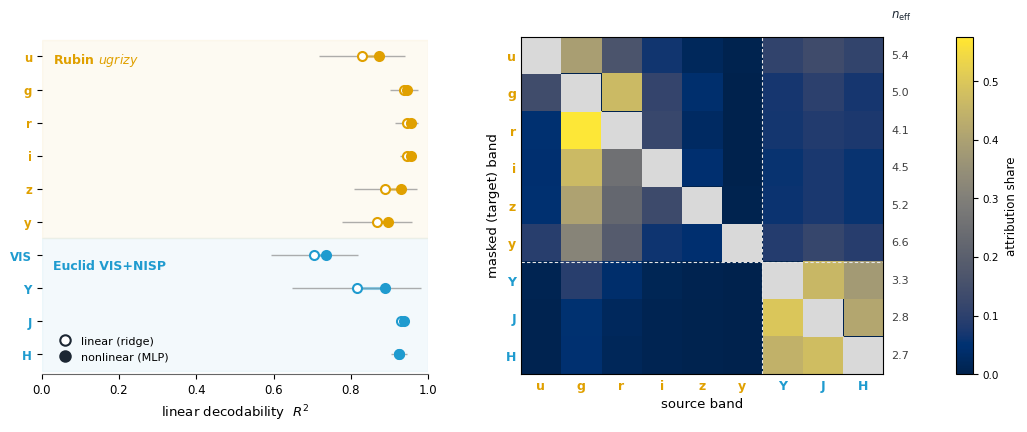

In [3]:
C_RUBIN = '#e0a000'; C_EUCLID = '#1f9bcf'; INK = '#1c2733'
cols  = [C_RUBIN]*6 + [C_EUCLID]*4   # 10-band (left)
cols9 = [C_RUBIN]*6 + [C_EUCLID]*3   # 9-band  (right, VIS removed)
yv = np.arange(10)[::-1]

fig = plt.figure(figsize=(11.0, 4.5))
gs = GridSpec(1, 2, figure=fig, width_ratios=[1.0, 1.18], wspace=0.22,
              left=0.07, right=0.92, top=0.90, bottom=0.15)
axp = fig.add_subplot(gs[0, 0])
axh = fig.add_subplot(gs[0, 1])

# ---------- left: decodability (probe dumbbell) ----------
axp.axhspan(3.5, 9.5, color=C_RUBIN,  alpha=0.05, zorder=0)
axp.axhspan(-0.5, 3.5, color=C_EUCLID, alpha=0.05, zorder=0)
for i in range(10):
    c = cols[i]
    axp.plot([ridge[i]-ridgesd[i], ridge[i]+ridgesd[i]], [yv[i], yv[i]],
             color='0.55', lw=1.0, alpha=0.7, zorder=1, solid_capstyle='butt')
    axp.plot([ridge[i], mlp[i]], [yv[i], yv[i]], color=c, lw=2.2, alpha=0.45,
             solid_capstyle='round', zorder=2)
    axp.scatter(ridge[i], yv[i], s=42, facecolor='white', edgecolor=c, lw=1.5, zorder=3)
    axp.scatter(mlp[i],   yv[i], s=42, facecolor=c,       edgecolor=c, lw=1.5, zorder=3)
axp.set_yticks(yv); axp.set_yticklabels(LABELS, fontsize=9.5)
for tk, c in zip(axp.get_yticklabels(), cols): tk.set_color(c); tk.set_fontweight('bold')
axp.set_ylim(-0.6, 9.6); axp.set_xlim(0.0, 1.0)
axp.set_xlabel('linear decodability  $R^2$', fontsize=9.5)
axp.tick_params(labelsize=8.5)
for s in ('top','right','left'): axp.spines[s].set_visible(False)
axp.spines['bottom'].set_color('0.4')
#axp.set_title('decodability', fontsize=10.5, color=INK, weight='bold', pad=6)
axp.text(0.03, 0.955, 'Rubin $ugrizy$', transform=axp.transAxes, ha='left', va='top',
         fontsize=9, color=C_RUBIN, weight='bold')
axp.text(0.03, 0.34, 'Euclid VIS+NISP', transform=axp.transAxes, ha='left', va='top',
         fontsize=9, color=C_EUCLID, weight='bold')
leg = [Line2D([0],[0], marker='o', ls='none', mfc='white', mec=INK, mew=1.5, ms=7.5, label='linear (ridge)'),
       Line2D([0],[0], marker='o', ls='none', mfc=INK,    mec=INK, mew=1.5, ms=7.5, label='nonlinear (MLP)')]
axp.legend(handles=leg, loc='lower left', fontsize=8, frameon=False, handletextpad=0.4, borderaxespad=0.7)

# ---------- right: information routing (VIS-removed 9x9 attribution) ----------
# cividis (dark blue -> gold) harmonizes with the Euclid-blue / Rubin-gold convention.
nb = len(B9)
im = axh.imshow(M9, cmap='cividis', vmin=0, vmax=float(M9.max()), aspect='auto')
for i in range(nb):  # gray the (masked) diagonal
    axh.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, facecolor='0.85', edgecolor='none', zorder=2))
axh.set_xticks(range(nb)); axh.set_yticks(range(nb))
axh.set_xticklabels(L9, fontsize=9); axh.set_yticklabels(L9, fontsize=9)
for tk, c in zip(axh.get_xticklabels(), cols9): tk.set_color(c); tk.set_fontweight('bold')
for tk, c in zip(axh.get_yticklabels(), cols9): tk.set_color(c); tk.set_fontweight('bold')
axh.set_xlabel('source band', fontsize=9.5); axh.set_ylabel('masked (target) band', fontsize=9.5)
axh.tick_params(length=0)
axh.axhline(5.5, color='0.9', lw=0.8, ls=(0,(3,2))); axh.axvline(5.5, color='0.9', lw=0.8, ls=(0,(3,2)))
axh.set_xlim(-0.5, nb-0.5); axh.set_ylim(nb-0.5, -0.5)
#axh.set_title('information routing', fontsize=10.5, color=INK, weight='bold', pad=6)
# per-target effective number of source bands (2^entropy), right margin
axh.text(nb-0.30, -1.05, '$n_{\\rm eff}$', fontsize=8.5, color=INK, ha='left', va='center', clip_on=False)
for i in range(nb):
    axh.text(nb-0.30, i, f'{neff[i]:.1f}', fontsize=8, color='0.25', ha='left', va='center', clip_on=False)
cb = fig.colorbar(im, ax=axh, fraction=0.045, pad=0.16)
cb.set_label('attribution share', fontsize=8.5); cb.ax.tick_params(labelsize=7.5)

out = FIGDIR / 'fig4_probe.png'
fig.savefig(out, dpi=400, bbox_inches='tight', facecolor='white')
print('saved', out)
plt.show()